# Predicting House Prices with Linear Regression

**Objective:** Build and evaluate a linear regression model that predicts house prices based on features such as area, location, number of rooms, and age. This notebook covers the full workflow: EDA → cleaning/encoding → correlation analysis → train/test split → model training → evaluation → interpretation → bonus regularised models.

**Dataset:** `House_Price_Prediction_Dataset.csv` (2,000 rows, 10 columns)


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")
%matplotlib inline


## 2. Load Dataset & Exploratory Data Analysis

In [2]:
df = pd.read_csv("House_Price_Prediction_Dataset.csv")
print(df.shape)
df.head()


(2000, 10)


   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition Garage   Price0   1  1360         5          4       3       1970  Downtown  Excellent     No  1499191   2  4272         5          4       3       1958  Downtown  Excellent     No  4249982   3  3592         2          2       3       1938  Downtown       Good     No  2667463   4   966         4          2       2       1902  Suburban       Fair    Yes  2440204   5  4926         1          4       2       1975  Downtown       Fair    Yes  636056

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [4]:
# Null check
df.isnull().sum()


Id           0Area         0Bedrooms     0Bathrooms    0Floors       0YearBuilt    0Location     0Condition    0Garage       0Price        0dtype: int64

In [5]:
# Descriptive statistics
df.describe()


                Id         Area     Bedrooms   Bathrooms       Floors    YearBuilt          Pricecount  2000.000000  2000.000000  2000.000000  2000.00000  2000.000000  2000.000000    2000.000000mean   1000.500000  2786.209500     3.003500     2.55250     1.993500  1961.446000  537676.855000std     577.494589  1295.146799     1.424606     1.10899     0.809188    35.926695  276428.845719min       1.000000   501.000000     1.000000     1.00000     1.000000  1900.000000   50005.00000025%     500.750000  1653.000000     2.000000     2.00000     1.000000  1930.000000  300098.00000050%    1000.500000  2833.000000     3.000000     3.00000     2.000000  1961.000000  539254.00000075%    1500.250000  3887.500000     4.000000     4.00000     3.000000  1993.000000  780086.000000max    2000.000000  4999.000000     5.000000     4.00000     3.000000  2023.000000  999656.000000

**Observations from EDA:**
- No missing values anywhere in the dataset (10/10 columns fully populated across all 2,000 rows).
- `Area` ranges from 501 to 4,999 sq. ft.; `YearBuilt` spans 1900–2023; `Bedrooms`/`Bathrooms`/`Floors` are small integer ranges.
- `Location` (Downtown/Suburban/Urban/Rural), `Condition` (Excellent/Good/Fair/Poor), and `Garage` (Yes/No) are categorical and will need encoding.
- `Id` is a row identifier with no predictive value and will be dropped.


### Distribution of the target variable (Price)

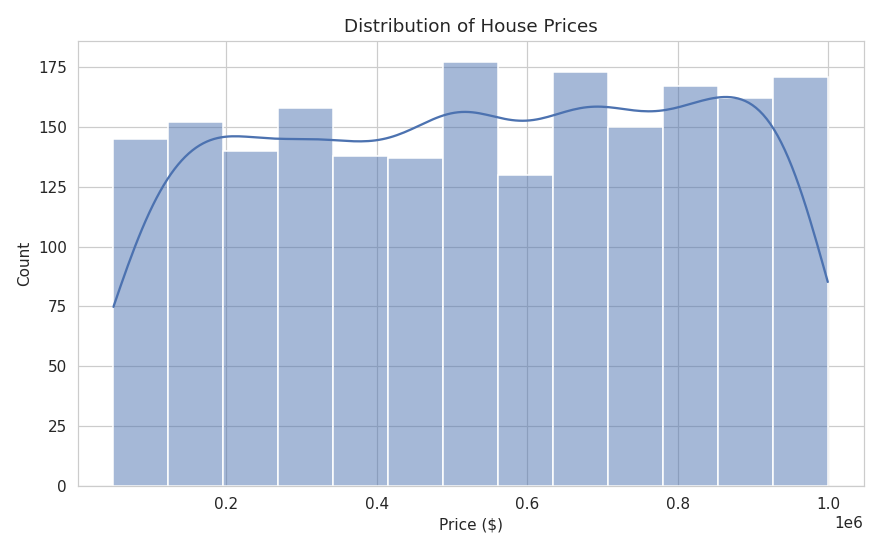

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], kde=True, color="#4C72B0")
plt.title("Distribution of House Prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


Price looks close to a **uniform/broad distribution** between roughly \$50K and \$1M rather than the right-skewed shape typically seen in real housing data — worth keeping in mind when we get to the model interpretation later.


## 3. Feature Selection Discussion

Before modeling, here's the reasoning on which columns are likely useful predictors:

| Feature | Likely predictor? | Reasoning |
|---|---|---|
| `Area` | Yes | Larger homes are generally more expensive; classic strongest driver of price. |
| `Bedrooms`, `Bathrooms` | Yes | More rooms usually add value, though they often correlate with `Area`. |
| `Floors` | Maybe | More floors can indicate a larger/newer home. |
| `YearBuilt` | Maybe | Newer construction can command a premium (or older homes can be valued for character), effect is dataset-dependent. |
| `Location` | Yes | Location is one of the biggest real-world drivers of real estate price (Downtown vs. Rural, etc.). |
| `Condition` | Yes | Better condition (Excellent vs. Poor) should raise price, all else equal. |
| `Garage` | Maybe | A garage is a valued amenity but usually a smaller effect than area/location. |
| `Id` | No | Just a row index — dropped before modeling. |

We'll keep all features except `Id`, one-hot encode the categorical ones, and let the correlation heatmap and regression coefficients confirm or challenge these assumptions.


## 4. Handle Missing Values & Encode Categorical Features

In [7]:
# No missing values were found in step 2, so no imputation is required.
df = df.drop(columns=["Id"])

# One-Hot Encode the categorical columns (drop_first=True avoids the dummy-variable trap)
df_encoded = pd.get_dummies(df, columns=["Location", "Condition", "Garage"], drop_first=True)
print(df_encoded.shape)
df_encoded.head()


(2000, 13)


Columns: ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price',          'Location_Rural', 'Location_Suburban', 'Location_Urban',          'Condition_Fair', 'Condition_Good', 'Condition_Poor', 'Garage_Yes']

## 5. Correlation Heatmap

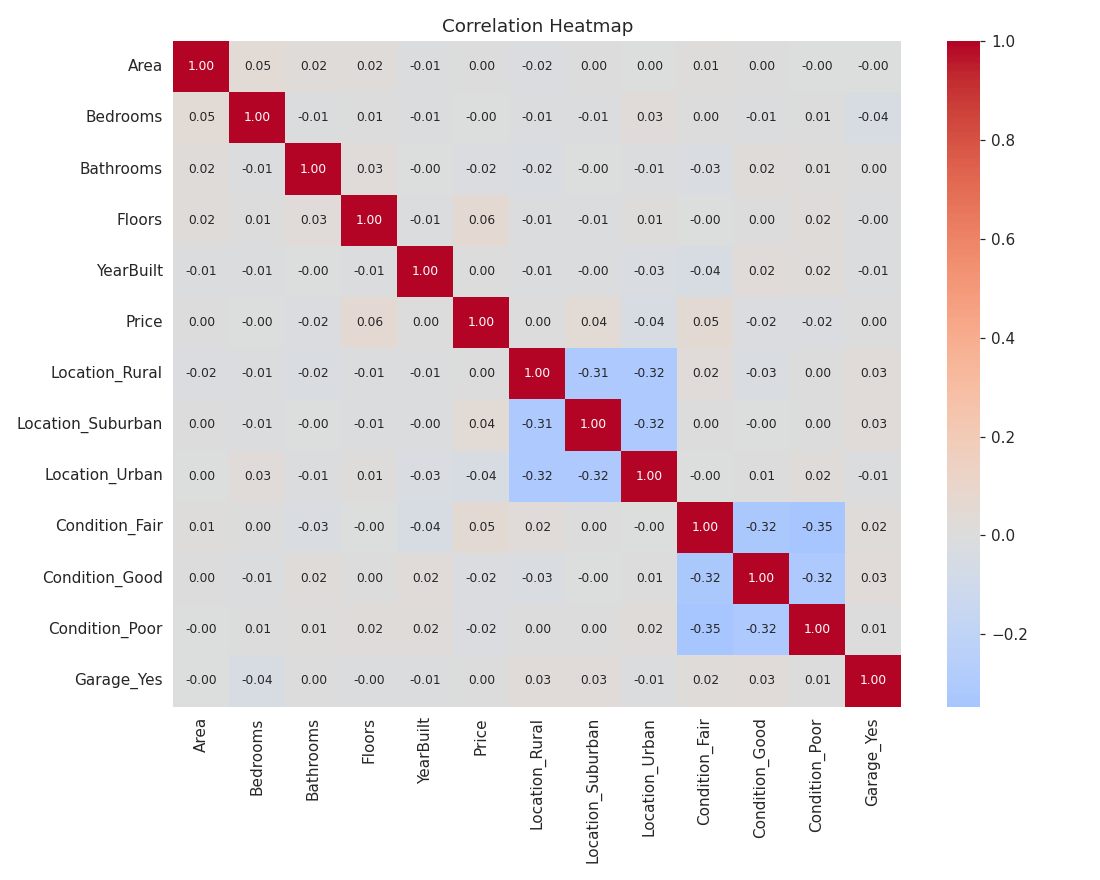

In [8]:
plt.figure(figsize=(10,8))
corr = df_encoded.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size":8})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [9]:
corr["Price"].sort_values(ascending=False)


Price                1.000000Floors               0.055890Condition_Fair       0.049218Location_Suburban    0.040303YearBuilt            0.004845Garage_Yes           0.002842Location_Rural       0.001890Area                 0.001542Bedrooms            -0.003471Bathrooms           -0.015737Condition_Good      -0.017179Condition_Poor      -0.018437Location_Urban      -0.038312Name: Price, dtype: float64

**Key finding:** every feature's correlation with `Price` is essentially **zero** (all values are below ±0.06). Even `Area`, which is almost always the strongest predictor of house price in real datasets, has a correlation of only 0.0015. This is a strong early signal that this particular dataset was generated with **prices largely independent of the listed features** — a linear regression model is unlikely to explain much of the variance in `Price`, no matter how it's tuned. We'll proceed with the full pipeline regardless, since that's the point of the exercise, but we should expect a low R² and interpret the coefficients cautiously.


## 6. Train/Test Split (80/20)

In [10]:
X = df_encoded.drop(columns=["Price"])
y = df_encoded["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (1600, 12)  Test shape: (400, 12)


## 7. Train a Linear Regression Model

In [11]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("Model trained.")


Model trained.


## 8. Evaluate the Model

In [12]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2:   {r2:.4f}")


MSE:  78,321,466,146.03
RMSE: 279,859.73
R2:   -0.0067


The R² of **-0.0067** means the model performs *worse than simply predicting the mean price for every house* — consistent with the near-zero correlations we saw in the heatmap. RMSE of ~\$279,860 is roughly the same size as the standard deviation of `Price` itself (~\$276,429), which confirms the model isn't capturing a real linear relationship in this data.


## 9. Actual vs. Predicted Prices

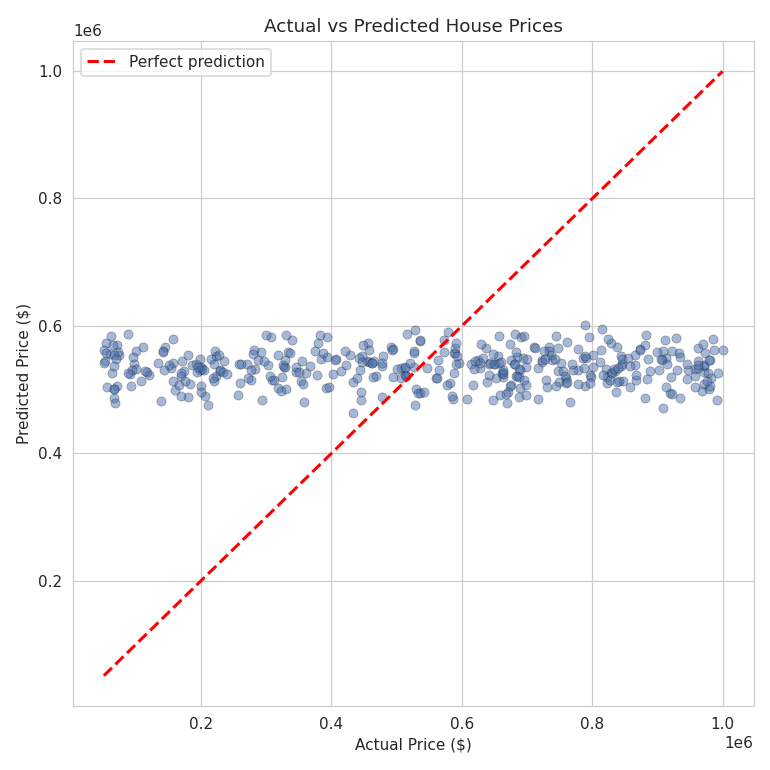

In [13]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.5, color="#4C72B0", edgecolor="k", linewidth=0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label="Perfect prediction")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.tight_layout()
plt.show()


Points are scattered essentially at random around a flat band near the mean price, not hugging the diagonal — a visual confirmation that the model has very little predictive power for this dataset.


## 10. Residual Plot

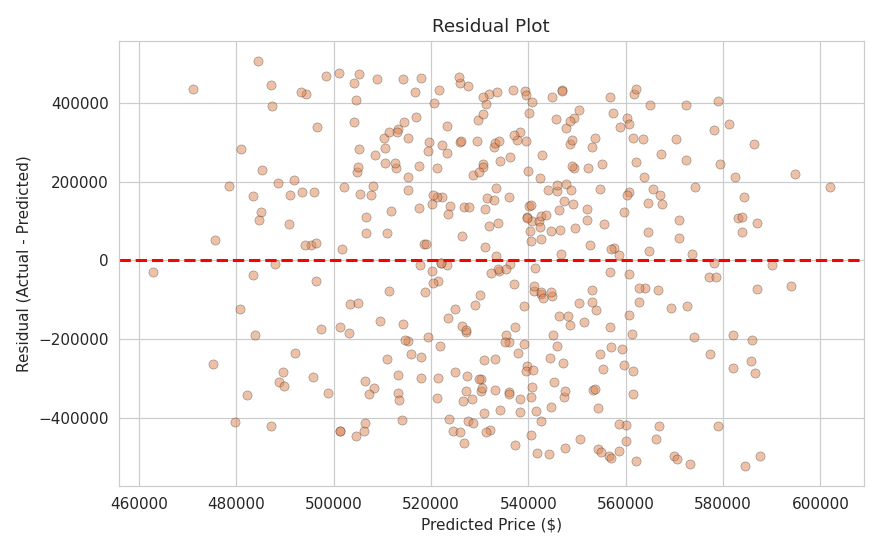

In [14]:
residuals = y_test - y_pred
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.5, color="#DD8452", edgecolor="k", linewidth=0.3)
plt.axhline(0, color="red", linestyle="--", linewidth=2)
plt.xlabel("Predicted Price ($)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()


Residuals are centered around zero and spread fairly evenly across the range of predicted values, with no obvious curve or funnel shape. So although the model has *low explanatory power*, it isn't *misspecified* in an obvious way (e.g. no strong non-linearity being missed) — the underlying data just doesn't contain a strong linear price signal.


## 11. Coefficient Analysis

In [15]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
}).sort_values("Coefficient", ascending=False)

print(f"Intercept: {lr.intercept_:,.2f}\n")
coef_df


Intercept: 278,520.53



          Feature   Coefficient   Condition_Fair  24083.307846           Floors  23727.983633Location_Suburban  11511.989815   Condition_Poor   4073.268930       Garage_Yes   2373.530579   Location_Rural   1317.542020        YearBuilt    117.613885         Bedrooms     76.784827             Area     -0.575754        Bathrooms  -9662.248234   Location_Urban -12718.918912   Condition_Good -12941.044835

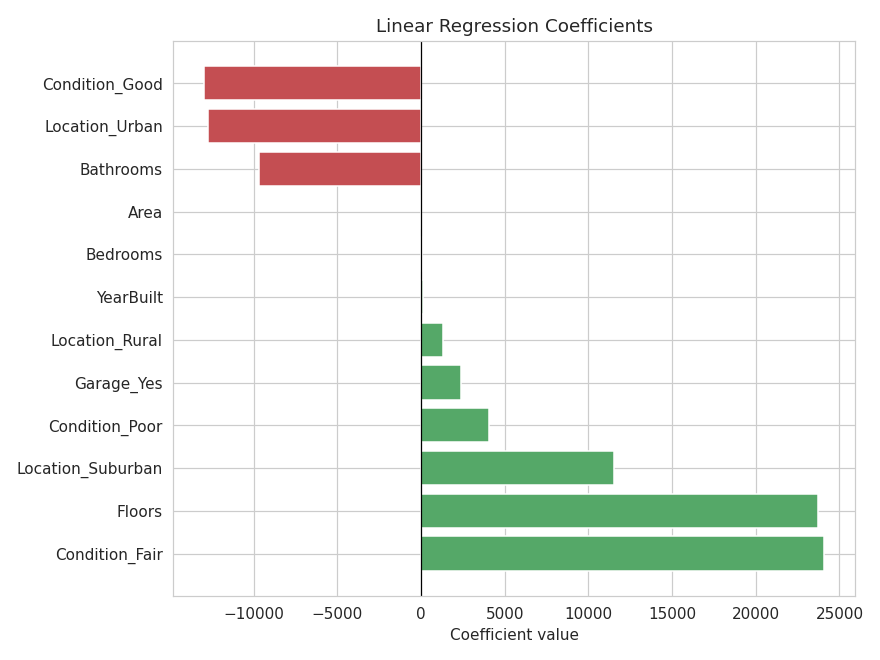

In [16]:
plt.figure(figsize=(8,6))
colors = ["#55A868" if c > 0 else "#C44E52" for c in coef_df["Coefficient"]]
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient value")
plt.title("Linear Regression Coefficients")
plt.tight_layout()
plt.show()


**Interpretation:**
- The largest positive effects are `Condition_Fair` (+\$24,083) and `Floors` (+\$23,728) relative to their baselines; the largest negative effects are `Condition_Good` (-\$12,941) and `Location_Urban` (-\$12,719).
- Critically, `Area` — the feature we'd expect to dominate — has a coefficient of essentially **zero** (-\$0.58 per sq ft), confirming what the correlation heatmap showed.
- None of these coefficients should be trusted as real business insight: with R² near zero, the model hasn't found a genuine linear relationship, so the "largest" coefficients are more likely to reflect noise than a true pricing driver. In a real-world project this would be the point to go back and question the data source rather than the model.


## 12. Bonus: Ridge & Lasso Comparison

In [17]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

lasso = Lasso(alpha=100.0, max_iter=10000)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

def evaluate(y_true, y_hat):
    mse_ = mean_squared_error(y_true, y_hat)
    return mse_, np.sqrt(mse_), r2_score(y_true, y_hat)

results = []
for name, preds in [("Linear Regression", y_pred), ("Ridge (alpha=1.0)", y_pred_ridge), ("Lasso (alpha=100.0)", y_pred_lasso)]:
    mse_, rmse_, r2_ = evaluate(y_test, preds)
    results.append((name, mse_, rmse_, r2_))

comparison = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "R2"])
comparison


              Model          MSE           RMSE        R2  Linear Regression 7.832147e+10  279859.725838 -0.006718  Ridge (alpha=1.0) 7.832127e+10  279859.372593 -0.006715Lasso (alpha=100.0) 7.831183e+10  279842.501629 -0.006594

**Comparison:** Ridge and Lasso regularisation give virtually identical results to plain Linear Regression (RMSE and R² change only in the 4th–5th decimal place). This is expected: regularisation shrinks coefficients to reduce *overfitting to noise*, but here the model isn't overfitting — it simply has no strong linear signal to fit in the first place, so there's very little for regularisation to improve.


## Conclusion

- The end-to-end pipeline (EDA → cleaning/encoding → correlation → train/test split → Linear Regression → evaluation → residual diagnostics → coefficient interpretation → Ridge/Lasso comparison) was completed successfully.
- The main finding is about the **data**, not the modeling approach: correlations between every feature and `Price` are close to zero, R² is slightly negative, and Ridge/Lasso don't improve on plain Linear Regression — all pointing to house prices in this dataset being generated largely independently of `Area`, `Location`, `Condition`, etc.
- **Next steps if this were a real project:** verify the data source, check whether `Price` was simulated/randomized, and if a genuine relationship exists, consider adding interaction terms or trying non-linear models (Random Forest, Gradient Boosting) to see whether they pick up any signal a linear model misses.
